In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from shapely.geometry import Point, LineString
from shapely.ops import linemerge

In [2]:
data = Path("/home/py/groundwater/data/bow_valley/")

In [3]:
# natural
banff = pd.read_csv(data/'stream'/'Stage.Working@05BB001.20110101_corrected.csv', skiprows=14, usecols=[1, 2], parse_dates=[0], index_col=0).squeeze()
banff = banff.resample('h').mean()
banff = banff+1376.388

# regularized
calgary = pd.read_csv(data/'stream'/'Stage.Working@05BH004.20110101_corrected.csv', skiprows=14, usecols=[1, 2], parse_dates=[0], index_col=0).squeeze()
calgary = calgary.resample('h').mean()
calgary = calgary+1034.652

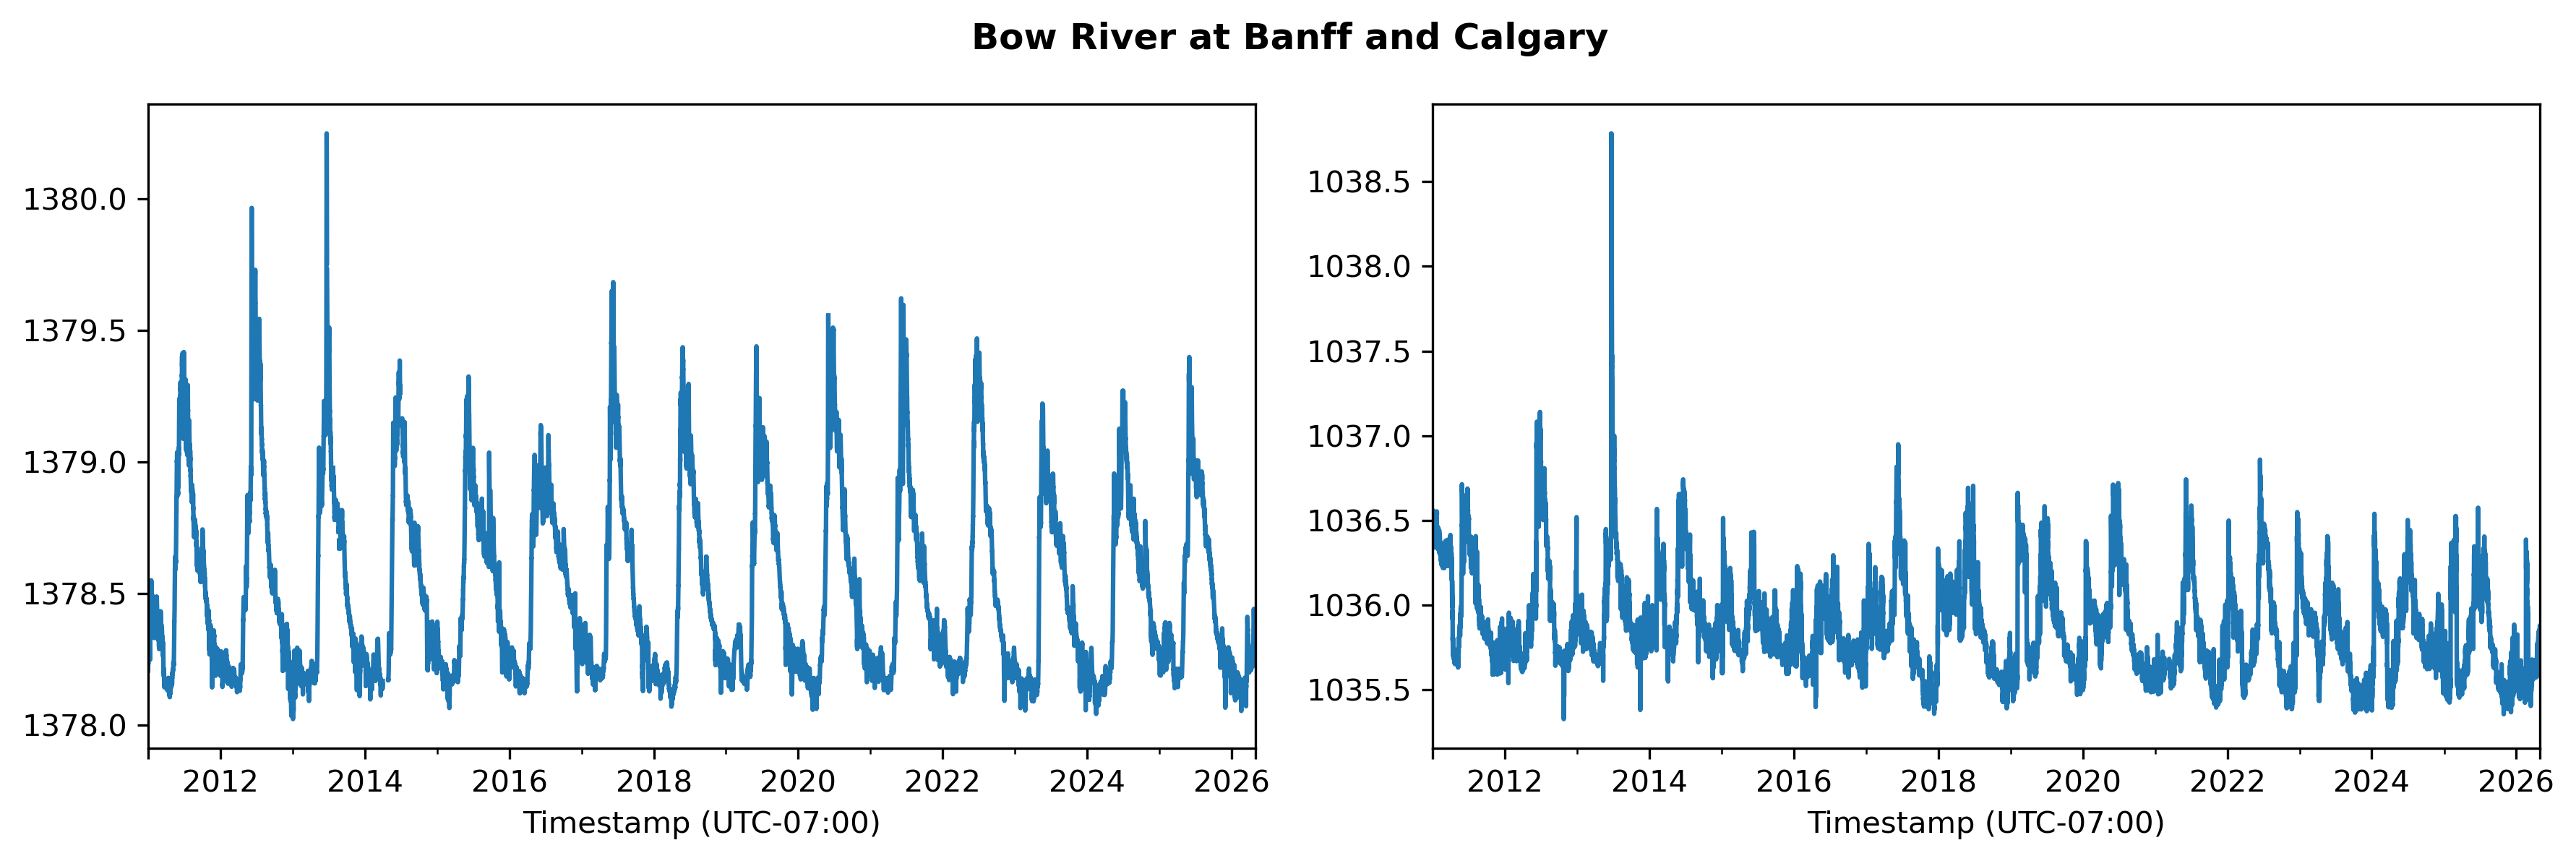

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
banff.plot(ax=ax1)
calgary.plot(ax=ax2)
plt.suptitle('Bow River at Banff and Calgary', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
CRS_M = 32611

In [7]:
RIVER_PATH = data/'stream'/'river_line.gpkg'
river = gpd.read_file(RIVER_PATH).to_crs(epsg=CRS_M)

In [31]:
GAUGE = {
    "banff":   (51.172222, -115.571667),
    "calgary": (51.050000, -114.051389),
}

g = gpd.GeoDataFrame(
    {"name": list(GAUGE)},
    geometry=[Point(lon, lat) for lat, lon in GAUGE.values()],
    crs=4269,
).to_crs(epsg=CRS_M)

In [32]:
def to_single_line(gdf):
    """Return one shapely LineString from a GeoDataFrame of line(s)."""
    geoms = list(gdf.geometry)
    if len(geoms) == 1 and geoms[0].geom_type == "LineString":
        return geoms[0]
    # linemerge stitches segments that share endpoints
    return linemerge(geoms if len(geoms) > 1 else geoms[0])

In [33]:
line = to_single_line(river)

In [34]:
print("river geometry type:", line.geom_type)
print("river length (km):  ", round(line.length / 1000, 1))

river geometry type: LineString
river length (km):   132.7


In [35]:
df = pd.read_csv(data/'gown'/'wells.csv')
wells = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs=4326, # source CRS of lon/lat
).to_crs(epsg=CRS_M)

In [36]:
wells

,well,lon,lat,geometry
0,764,-115.38113,51.12767,POINT (613280.242 5665268.522)
1,760,-115.36644,51.10731,POINT (614358.375 5663027.281)
2,759,-115.15419,51.05894,POINT (629350.905 5658000.094)
3,364,-115.11535,51.07367,POINT (632030.613 5659706.897)


In [37]:
banff_pt   = g.loc[g["name"] == "banff",   "geometry"].iloc[0]
calgary_pt = g.loc[g["name"] == "calgary", "geometry"].iloc[0]

In [38]:
a_banff   = line.project(banff_pt,   normalized=True)
a_calgary = line.project(calgary_pt, normalized=True)

In [39]:
print(f"Banff   alpha={a_banff:.3f}  snap={line.distance(banff_pt):.0f} m")
print(f"Calgary alpha={a_calgary:.3f}  snap={line.distance(calgary_pt):.0f} m")

Banff   alpha=0.000  snap=181 m
Calgary alpha=1.000  snap=76 m


In [40]:
wells["alpha"]    = [line.project(pt, normalized=True) for pt in wells.geometry]
wells["river_km"] = [line.project(pt)/1000 for pt in wells.geometry]
wells["snap_m"]   = [line.distance(pt) for pt in wells.geometry]

In [41]:
wells

,well,lon,lat,geometry,alpha,river_km,snap_m
0,764,-115.38113,51.12767,POINT (613280.242 5665268.522),0.122547,16.265895,959.796294
1,760,-115.36644,51.10731,POINT (614358.375 5663027.281),0.137094,18.196701,1081.028374
2,759,-115.15419,51.05894,POINT (629350.905 5658000.094),0.288866,38.341517,140.785892
3,364,-115.11535,51.07367,POINT (632030.613 5659706.897),0.313803,41.651474,608.305895


In [42]:
common = banff.index.intersection(calgary.index)

In [43]:
banff, calgary = banff.loc[common], calgary.loc[common]
print(f"{len(common)} shared timestamps "
      f"({common.min().date()} to {common.max().date()})")

134376 shared timestamps (2010-12-31 to 2026-04-30)


In [44]:
alpha = wells["alpha"].to_numpy() # (N,)  one value per well
hb = banff.to_numpy()[:, None] # (T,1) column: time down the rows
hc = calgary.to_numpy()[:, None] # (T,1)
a = alpha[None, :] # (1,N) row: wells across the cols

In [46]:
wse = (1 - a) * hb + a * hc # (T,1)*(1,N) -> (T,N)
 
wse_wells = pd.DataFrame(
    wse, index=common, columns=wells["well"].astype(str)
)

wse_wells.head()

well,764,760,759,364
Timestamp (UTC-07:00),,,,
2010-12-31 17:00:00,1336.335203,1331.364752,1279.506174,1270.985391
2010-12-31 18:00:00,1336.339068,1331.368838,1279.512576,1270.992174
2010-12-31 19:00:00,1336.341778,1331.371574,1279.515579,1270.995220
2010-12-31 20:00:00,1336.343609,1331.373267,1279.515832,1270.995236
2010-12-31 21:00:00,1336.347058,1331.376621,1279.518201,1270.997444


In [47]:
wse_wells.to_csv('bow_river_interpolated.csv')

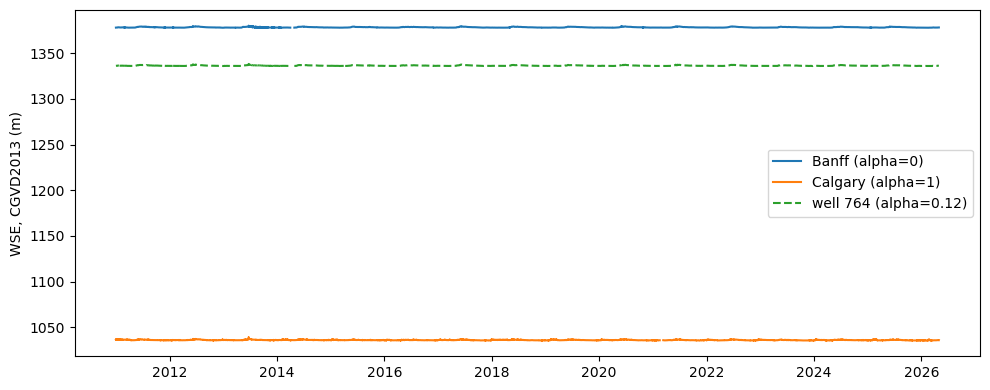

In [48]:
w0 = wse_wells.columns[0]
plt.figure(figsize=(10, 4))
plt.plot(common, banff,   label="Banff (alpha=0)")
plt.plot(common, calgary, label="Calgary (alpha=1)")
plt.plot(wse_wells.index, wse_wells[w0], "--",
         label=f"well {w0} (alpha={wells['alpha'].iloc[0]:.2f})")
plt.ylabel("WSE, CGVD2013 (m)")
plt.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='Timestamp (UTC-07:00)'>

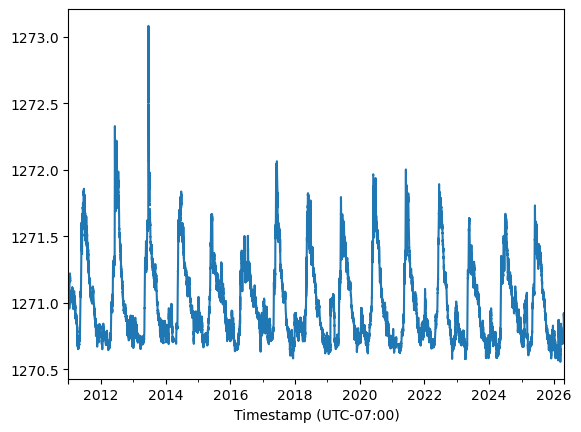

In [49]:
wse_wells['364'].plot()

<Axes: xlabel='Timestamp (UTC-07:00)'>

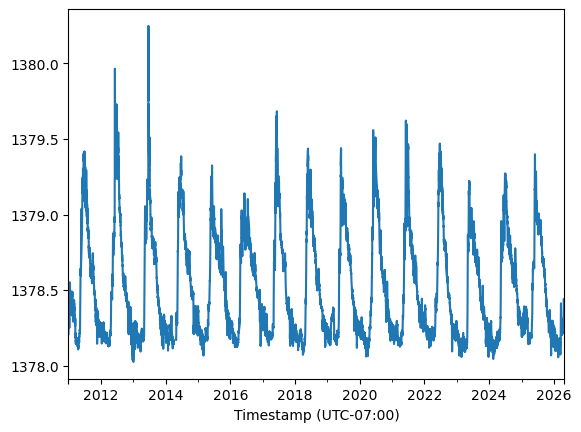

In [50]:
banff.plot()

<Axes: xlabel='Timestamp (UTC-07:00)'>

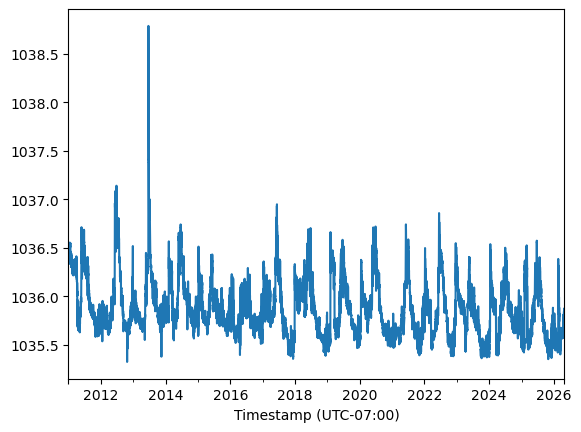

In [51]:
calgary.plot()

In [52]:
import contextily as cx

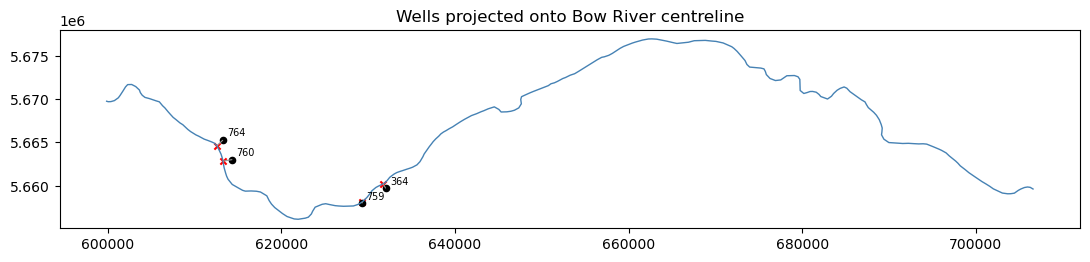

In [53]:
# projected point on the river for each well
# interpolate = inverse of project: normalized distance (0-1) -> Point on line
proj_pts = [line.interpolate(a, normalized=True) for a in wells["alpha"]]

# connector: well -> its projection (only for drawing)
connectors = [LineString([w, p]) for w, p in zip(wells.geometry, proj_pts)]


fig, ax = plt.subplots(figsize=(11, 7))

gpd.GeoSeries([line], crs=wells.crs).plot(ax=ax, color="steelblue", lw=1)          # centreline
gpd.GeoSeries(connectors, crs=wells.crs).plot(ax=ax, color="0.6", lw=0.8)          # connectors
gpd.GeoSeries(proj_pts, crs=wells.crs).plot(ax=ax, color="red", marker="x", markersize=20)  # projections
wells.plot(ax=ax, color="black", markersize=20)                                    # wells

# cx.add_basemap(ax, crs=wells.crs, source=cx.providers.Esri.WorldImagery)

# label each well so you can tie a suspicious one back to its ID
for _, r in wells.iterrows():
    ax.annotate(r['well'], (r.geometry.x, r.geometry.y),
                fontsize=7, xytext=(3, 3), textcoords="offset points")

ax.set_aspect("equal")   # essential — otherwise distances are visually distorted
ax.set_title("Wells projected onto Bow River centreline")
plt.tight_layout()
plt.show()